# Image Captioning with Transformers
### Encoder-Decoder Architecture

<img src="../data/llm_architecture_comparison.png" width="600" align="center">
<br>

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from tqdm.notebook import trange, tqdm
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch.distributions import Categorical

import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision

# You'll need to install HugginFace's transformers library!
# https://huggingface.co/docs/transformers/en/index
# Make sure you are using the lastest version!
from transformers import AutoTokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"

torch.backends.cuda.matmul.allow_tf32 = True

In [80]:
# Create target directory
import os
base = "coco_captions"
os.makedirs(base, exist_ok=True)
print("Target directory:", base)


Target directory: coco_captions


In [81]:
import urllib.request
import os

# Create download function
def download_file(url, filename):
    """Download a file from URL to filename with progress indication"""
    if os.path.exists(filename):
        print(f"{filename} already exists, skipping download.")
        return
    
    print(f"Downloading {filename}...")
    try:
        urllib.request.urlretrieve(url, filename)
        print(f"Downloaded {filename} successfully!")
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

# Images
download_file("http://images.cocodataset.org/zips/train2014.zip", "train2014.zip")  # official COCO mirror
download_file("http://images.cocodataset.org/zips/val2014.zip", "val2014.zip")      # official COCO mirror

# Annotations (contains captions JSONs, e.g., captions_train2014.json, captions_val2014.json)
download_file("http://images.cocodataset.org/annotations/annotations_trainval2014.zip", "annotations_trainval2014.zip")

train2014.zip already exists, skipping download.
val2014.zip already exists, skipping download.
annotations_trainval2014.zip already exists, skipping download.


In [82]:
# # # # Unzip images
# # # !unzip -q train2014.zip -d /content/coco_captions/
# # # !unzip -q val2014.zip   -d /content/coco_captions/

# # # # Unzip annotations
# # # !unzip -q annotations_trainval2014.zip -d /content/coco_captions/

# # # # Ensure final names match your required structure
# # # # After extraction, folders are already named train2014, val2014, and annotations
# # # !ls -lah /content/coco_captions



# # Extract downloaded archives into local coco_captions folder
# import os, zipfile

# base = os.path.abspath("coco_captions")
# os.makedirs(base, exist_ok=True)
# print("Target directory:", base)

# def extract(zip_path, dest_dir):
#     if not os.path.exists(zip_path):
#         print(f"Missing {zip_path}; skipping.")
#         return
#     print(f"Extracting {zip_path} -> {dest_dir}")
#     with zipfile.ZipFile(zip_path) as zf:
#         zf.extractall(dest_dir)
#     print("Done.")

# extract("train2014.zip", base)
# extract("val2014.zip", base)
# extract("annotations_trainval2014.zip", base)

# print("Top-level contents in", base, ":")
# for name in os.listdir(base):
#     print("-", name)

In [116]:
# Define the learning rate for the optimizer
learning_rate = 1e-4

# Image size
image_size = 128

# Define the number of epochs for training
nepochs = 200

# Define the batch size for mini-batch gradient descent
batch_size = 128

# You'll need to download the COCO Captions dataset from the COCO Datsets
# https://cocodataset.org/#download
# For the Captions dataset you'll need to download:
# Images:
# 2014 Train images [83K/13GB]
# 2014 Val images [41K/6GB]
# Annotations:
# 2014 Train/Val annotations [241MB]

# Unzip them all into a directory called "coco_captions" and rename the folders
# train2014
# val2014
# annotations

# Define the root directory of the dataset to the extraction location
# `base` was created earlier as the absolute path to coco_captions
try:
    data_set_root = base
except NameError:
    import os
    data_set_root = os.path.abspath("coco_captions")

train_set = 'train2014'
validation_set = 'val2014'

train_image_path = os.path.join(data_set_root, train_set)
train_ann_file = os.path.join(data_set_root, 'annotations', 'captions_train2014.json')

val_image_path = os.path.join(data_set_root, validation_set)
val_ann_file = os.path.join(data_set_root, 'annotations', 'captions_val2014.json')

## Data processing and Tokenization

In [84]:
# Simple transform class to randomly sample one of the five captions
class SampleCaption(nn.Module):
    def __call__(self, sample):
        rand_index = random.randint(0, len(sample) - 1)
        return sample[rand_index]

In [85]:
# !pip install pycocotools

In [86]:
train_transform = transforms.Compose([transforms.Resize(image_size),
                                      transforms.RandomCrop(image_size),
                                      transforms.AutoAugment(),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                           std=[0.229, 0.224, 0.225])])

transform = transforms.Compose([transforms.Resize(image_size),
                                transforms.CenterCrop(image_size),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                     std=[0.229, 0.224, 0.225])])

train_dataset = datasets.CocoCaptions(root=train_image_path,
                                      annFile=train_ann_file,
                                      transform=train_transform,
                                      target_transform=SampleCaption())

eval_dataset = datasets.CocoCaptions(root=val_image_path,
                                     annFile=val_ann_file,
                                     transform=transform,
                                     target_transform=SampleCaption())

data_loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
data_loader_eval = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

loading annotations into memory...
Done (t=0.66s)
creating index...
index created!
loading annotations into memory...
Done (t=0.32s)
creating index...
index created!


In [87]:
# Create a dataloader itterable object
dataiter = next(iter(data_loader_eval))
# Sample from the itterable object
test_images, test_captions = dataiter

A small dog is curled up on top of the shoes


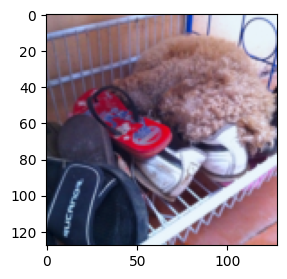

In [88]:
index = 0
# Lets visualise an entire batch of images!
plt.figure(figsize = (3,3))
out = torchvision.utils.make_grid(test_images[index].unsqueeze(0), 1, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

caption = test_captions[index]
print(caption)

In [89]:
# We'll use a pre-built Tokenizer for the BERT Model
# https://towardsdatascience.com/bert-explained-state-of-the-art-language-model-for-nlp-f8b21a9b6270
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [90]:
tokenizer.vocab_size

30522

In [91]:
tokens = tokenizer(test_captions, padding=True, truncation=True, return_tensors="pt")

In [92]:
token_ids = tokens['input_ids'][index]
tokens['input_ids']

tensor([[  101,  1037,  2235,  ...,     0,     0,     0],
        [  101,  1996,  2067,  ...,     0,     0,     0],
        [  101,  1996,  2317,  ...,     0,     0,     0],
        ...,
        [  101,  1037, 11190,  ...,     0,     0,     0],
        [  101,  1037,  2304,  ...,     0,     0,     0],
        [  101,  1037,  2611,  ...,     0,     0,     0]])

In [93]:
print(tokenizer.decode(token_ids))

[CLS] a small dog is curled up on top of the shoes [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [94]:
class TokenDrop(nn.Module):
    """For a batch of tokens indices, randomly replace a non-specical token.

    Args:
        prob (float): probability of dropping a token
        blank_token (int): index for the blank token
        num_special (int): Number of special tokens, assumed to be at the start of the vocab
    """

    def __init__(self, prob=0.1, blank_token=1, eos_token=102):
        self.prob = prob
        self.eos_token = eos_token
        self.blank_token = blank_token

    def __call__(self, sample):
        # Randomly sample a bernoulli distribution with p=prob
        # to create a mask where 1 means we will replace that token
        mask = torch.bernoulli(self.prob * torch.ones_like(sample)).long()

        # only replace if the token is not the eos token
        can_drop = (~(sample == self.eos_token)).long()
        mask = mask * can_drop

        # Do not replace the sos tokens
        mask[:, 0] = torch.zeros_like(mask[:, 0]).long()

        replace_with = (self.blank_token * torch.ones_like(sample)).long()

        sample_out = (1 - mask) * sample + mask * replace_with

        return sample_out

## Create Encoder-Decoder Network

In [95]:
def extract_patches(image_tensor, patch_size=16):
    # Get the dimensions of the image tensor
    bs, c, h, w = image_tensor.size()

    # Define the Unfold layer with appropriate parameters
    unfold = torch.nn.Unfold(kernel_size=patch_size, stride=patch_size)

    # Apply Unfold to the image tensor
    unfolded = unfold(image_tensor)

    # Reshape the unfolded tensor to match the desired output shape
    # Output shape: BSxLxH, where L is the number of patches in each dimension
    unfolded = unfolded.transpose(1, 2).reshape(bs, -1, c * patch_size * patch_size)

    return unfolded

# sinusoidal positional embeds
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


# Define a decoder module for the Transformer architecture
class Decoder(nn.Module):
    def __init__(self, num_emb, hidden_size=128, num_layers=3, num_heads=4):
        super(Decoder, self).__init__()

        # Create an embedding layer for tokens
        self.embedding = nn.Embedding(num_emb, hidden_size)
        # Initialize the embedding weights
        self.embedding.weight.data = 0.001 * self.embedding.weight.data

        # Initialize sinusoidal positional embeddings
        self.pos_emb = SinusoidalPosEmb(hidden_size)

        # Create multiple decoder layers
        decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_size, nhead=num_heads,
                                                   dim_feedforward=hidden_size * 4, dropout=0.0,
                                                   batch_first=True)
        # TransformerDecoder will clone the decoder_layer "num_layers" times
        self.decoder_layers = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Define a linear layer for output prediction
        self.fc_out = nn.Linear(hidden_size, num_emb)

    def forward(self, input_seq, encoder_output, input_padding_mask=None,
                encoder_padding_mask=None):
        # Embed the input sequence
        input_embs = self.embedding(input_seq)
        bs, l, h = input_embs.shape

        # Add positional embeddings to the input embeddings
        seq_indx = torch.arange(l, device=input_seq.device)
        pos_emb = self.pos_emb(seq_indx).reshape(1, l, h).expand(bs, l, h)
        embs = input_embs + pos_emb
        causal_mask = torch.triu(torch.ones(l, l, device=input_seq.device), 1).bool()

        # Pass the embeddings through each transformer block
        output = self.decoder_layers(tgt=embs, memory=encoder_output, tgt_mask=causal_mask,
                                     tgt_key_padding_mask=input_padding_mask,
                                     memory_key_padding_mask=encoder_padding_mask)

        return self.fc_out(output)


# Define an Vision Encoder module for the Transformer architecture
class VisionEncoder(nn.Module):
    def __init__(self, image_size, channels_in, patch_size=16, hidden_size=128, num_layers=3, num_heads=4):
        super(VisionEncoder, self).__init__()

        self.patch_size = patch_size
        self.fc_in = nn.Linear(channels_in * patch_size * patch_size, hidden_size)

        seq_length = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.empty(1, seq_length, hidden_size).normal_(std=0.02))

        # Create multiple transformer blocks as layers
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads,
                                                   dim_feedforward=hidden_size * 4, dropout=0.0,
                                                   batch_first=True)
        # TransformerEncoder will clone the encoder_layer "num_layers" times
        self.encoder_layers = nn.TransformerEncoder(encoder_layer, num_layers)

    def forward(self, image):
        bs = image.shape[0]

        patch_seq = extract_patches(image, patch_size=self.patch_size)
        patch_emb = self.fc_in(patch_seq)

        # Add a unique embedding to each token embedding
        embs = patch_emb + self.pos_embedding

        # Pass the embeddings through each transformer block
        output = self.encoder_layers(embs)

        return output


# Define an Vision Encoder-Decoder module for the Transformer architecture
class VisionEncoderDecoder(nn.Module):
    def __init__(self, image_size, channels_in, num_emb, patch_size=16,
                 hidden_size=128, num_layers=(3, 3), num_heads=4):
        super(VisionEncoderDecoder, self).__init__()

        # Create an encoder and decoder with specified parameters
        self.encoder = VisionEncoder(image_size=image_size, channels_in=channels_in, patch_size=patch_size,
                               hidden_size=hidden_size, num_layers=num_layers[0], num_heads=num_heads)

        self.decoder = Decoder(num_emb=num_emb, hidden_size=hidden_size,
                               num_layers=num_layers[1], num_heads=num_heads)

    def forward(self, input_image, target_seq, padding_mask):
        # Generate padding masks for the target sequence
        bool_padding_mask = padding_mask == 0

        # Encode the input sequence
        encoded_seq = self.encoder(image=input_image)

        # Decode the target sequence using the encoded sequence
        decoded_seq = self.decoder(input_seq=target_seq,
                                   encoder_output=encoded_seq,
                                   input_padding_mask=bool_padding_mask)
        return decoded_seq

## Initialise Model and Optimizer

In [96]:
# Check if GPU is available, set device accordingly
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Embedding Size
hidden_size = 192

# Number of Transformer blocks for the (Encoder, Decoder)
num_layers = (6, 6)

# MultiheadAttention Heads
num_heads = 8

# Size of the patches
patch_size = 8

# Create model
caption_model = VisionEncoderDecoder(image_size=image_size, channels_in=test_images.shape[1],
                                     num_emb=tokenizer.vocab_size, patch_size=patch_size,
                                     num_layers=num_layers, hidden_size=hidden_size,
                                     num_heads=num_heads).to(device)

# Initialize the optimizer with above parameters
optimizer = optim.Adam(caption_model.parameters(), lr=learning_rate)

# AMP scaler
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Define the loss function
loss_fn = nn.CrossEntropyLoss(reduction="none")

td = TokenDrop(0.5)

# Initialize the training loss logger
training_loss_logger = []
eval_loss_logger = []
start_epoch = 0

/tmp/ipykernel_37700/4286213023.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [97]:
# Let's see how many Parameters our Model has!
num_model_params = 0
for param in caption_model.parameters():
    num_model_params += param.flatten().shape[0]

print("-This Model Has %d (Approximately %d Million) Parameters!" % (num_model_params, num_model_params//1e6))

-This Model Has 18067194 (Approximately 18 Million) Parameters!


## Training

In [98]:
import os, pathlib

print("CWD:", os.getcwd())
print("Exists:", os.path.exists("captioning_model.pt"))
print("Absolute:", pathlib.Path("captioning_model.pt").resolve())


CWD: /home/safda/WorkSpace/AI_hashtag_generator
Exists: True
Absolute: /home/safda/WorkSpace/AI_hashtag_generator/captioning_model.pt


In [113]:
# Load Checkpoint (if exists)
start_epoch = 0
training_loss_logger = []
eval_loss_logger = []

try:
    cp = torch.load("captioning_model.pt")
    caption_model.load_state_dict(cp["model_state_dict"])
    optimizer.load_state_dict(cp["optimizer_state_dict"])
    training_loss_logger = cp["train_data_logger"]
    eval_loss_logger = cp["eval_data_logger"]
    start_epoch = cp["epoch"]
    print(f"Loaded checkpoint from epoch {start_epoch}")
except FileNotFoundError:
    print("No checkpoint found, starting from scratch")

Loaded checkpoint from epoch 43


In [129]:
# # Iterate over epochs
# for epoch in trange(start_epoch, nepochs, leave=False, desc="Epoch"):
#     # Set the model in training mode
#     caption_model.train()

#     # Iterate over the training data loader
#     for images, captions in tqdm(data_loader_train, desc="Training", leave=False):

#         images = images.to(device)

#         # Tokenize and pre-process the captions
#         tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt")
#         token_ids = tokens['input_ids'].to(device)
#         padding_mask = tokens['attention_mask'].to(device)
#         bs = token_ids.shape[0]

#         # Shift the input sequence to create the target sequence
#         target_ids = torch.cat((token_ids[:, 1:],
#                                 torch.zeros(bs, 1, device=device).long()), 1)

#         tokens_in = td(token_ids)
#         with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
#             # Forward pass
#             pred = caption_model(images, tokens_in, padding_mask=padding_mask)

#         # Compute the loss
#         loss_mask = (~(target_ids == 0)).float()
#         loss = (loss_fn(pred.transpose(1, 2), target_ids) * loss_mask).sum()/loss_mask.sum()

#         # Backpropagation
#         optimizer.zero_grad()
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         # Log the training loss
#         training_loss_logger.append(loss.item())

#     # Set the model in eval mode
#     caption_model.eval()
#     with torch.no_grad():
#         # Iterate over the training data loader
#         for images, captions in tqdm(data_loader_eval, desc="Eval", leave=False):

#             images = images.to(device)

#             # Tokenize and pre-process the captions
#             tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt")
#             token_ids = tokens['input_ids'].to(device)
#             padding_mask = tokens['attention_mask'].to(device)
#             bs = token_ids.shape[0]

#             # Shift the input sequence to create the target sequence
#             target_ids = torch.cat((token_ids[:, 1:],
#                                     torch.zeros(bs, 1, device=device).long()), 1)

#             with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
#                 # Forward pass
#                 pred = caption_model(images, token_ids, padding_mask=padding_mask)

#             # Compute the loss
#             loss_mask = (~(target_ids == 0)).float()
#             loss = (loss_fn(pred.transpose(1, 2), target_ids) * loss_mask).sum()/loss_mask.sum()

#             # Log the training loss
#             eval_loss_logger.append(loss.item())

#     # Quick save of the model every epoch
#     torch.save({'epoch': epoch + 1,
#                 'train_data_logger': training_loss_logger,
#                 'eval_data_logger': eval_loss_logger,
#                 'model_state_dict': caption_model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                  }, "captioning_model.pt")

# Continue Training Loop
print(f"Continuing training from epoch {start_epoch + 1} to {nepochs}")

# Iterate over epochs
for epoch in range(start_epoch, nepochs):
    print(f"Epoch {epoch+1}/{nepochs}")
    
    # Set the model in training mode
    caption_model.train()

    # Iterate over the training data loader
    for i, (images, captions) in enumerate(data_loader_train):
        if i % 10 == 0:  # Print every 10 batches
            print(f"  Training batch {i+1}/{len(data_loader_train)}")

        images = images.to(device)

        # Tokenize and pre-process the captions
        tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt")
        token_ids = tokens['input_ids'].to(device)
        padding_mask = tokens['attention_mask'].to(device)
        bs = token_ids.shape[0]

        # Shift the input sequence to create the target sequence
        target_ids = torch.cat((token_ids[:, 1:],
                                torch.zeros(bs, 1, device=device).long()), 1)

        tokens_in = td(token_ids)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            # Forward pass
            pred = caption_model(images, tokens_in, padding_mask=padding_mask)

        # Compute the loss
        loss_mask = (~(target_ids == 0)).float()
        loss = (loss_fn(pred.transpose(1, 2), target_ids) * loss_mask).sum()/loss_mask.sum()

        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Log the training loss
        training_loss_logger.append(loss.item())

    # Set the model in eval mode
    caption_model.eval()
    with torch.no_grad():
        # Iterate over the validation data loader
        for i, (images, captions) in enumerate(data_loader_eval):
            if i % 10 == 0:  # Print every 10 batches
                print(f"  Eval batch {i+1}/{len(data_loader_eval)}")

            images = images.to(device)

            # Tokenize and pre-process the captions
            tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt")
            token_ids = tokens['input_ids'].to(device)
            padding_mask = tokens['attention_mask'].to(device)
            bs = token_ids.shape[0]

            # Shift the input sequence to create the target sequence
            target_ids = torch.cat((token_ids[:, 1:],
                                    torch.zeros(bs, 1, device=device).long()), 1)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                # Forward pass
                pred = caption_model(images, token_ids, padding_mask=padding_mask)

            # Compute the loss
            loss_mask = (~(target_ids == 0)).float()
            loss = (loss_fn(pred.transpose(1, 2), target_ids) * loss_mask).sum()/loss_mask.sum()

            # Log the eval loss
            eval_loss_logger.append(loss.item())

    # Quick save of the model every epoch
    torch.save({'epoch': epoch + 1,
                'train_data_logger': training_loss_logger,
                'eval_data_logger': eval_loss_logger,
                'model_state_dict': caption_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                 }, "captioning_model.pt")
    
    print(f"Epoch {epoch+1} completed. Model saved.")

print("Training completed!")

Continuing training from epoch 61 to 200
Epoch 61/200
  Training batch 1/647


/tmp/ipykernel_37700/3016135014.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Training batch 11/647
  Training batch 21/647
  Training batch 31/647
  Training batch 41/647
  Training batch 51/647
  Training batch 61/647
  Training batch 71/647
  Training batch 81/647
  Training batch 91/647
  Training batch 101/647
  Training batch 111/647
  Training batch 121/647
  Training batch 131/647
  Training batch 141/647
  Training batch 151/647
  Training batch 161/647
  Training batch 171/647
  Training batch 181/647
  Training batch 191/647
  Training batch 201/647
  Training batch 211/647
  Training batch 221/647
  Training batch 231/647
  Training batch 241/647
  Training batch 251/647
  Training batch 261/647
  Training batch 271/647
  Training batch 281/647
  Training batch 291/647
  Training batch 301/647
  Training batch 311/647
  Training batch 321/647
  Training batch 331/647
  Training batch 341/647
  Training batch 351/647
  Training batch 361/647
  Training batch 371/647
  Training batch 381/647
  Training batch 391/647
  Training batch 401/647
  Trainin

/tmp/ipykernel_37700/3016135014.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Eval batch 11/317
  Eval batch 21/317
  Eval batch 31/317
  Eval batch 41/317
  Eval batch 51/317
  Eval batch 61/317
  Eval batch 71/317
  Eval batch 81/317
  Eval batch 91/317
  Eval batch 101/317
  Eval batch 111/317
  Eval batch 121/317
  Eval batch 131/317
  Eval batch 141/317
  Eval batch 151/317
  Eval batch 161/317
  Eval batch 171/317
  Eval batch 181/317
  Eval batch 191/317
  Eval batch 201/317
  Eval batch 211/317
  Eval batch 221/317
  Eval batch 231/317
  Eval batch 241/317
  Eval batch 251/317
  Eval batch 261/317
  Eval batch 271/317
  Eval batch 281/317
  Eval batch 291/317
  Eval batch 301/317
  Eval batch 311/317
Epoch 61 completed. Model saved.
Epoch 62/200
  Training batch 1/647
  Training batch 11/647
  Training batch 21/647
  Training batch 31/647
  Training batch 41/647
  Training batch 51/647
  Training batch 61/647
  Training batch 71/647
  Training batch 81/647
  Training batch 91/647
  Training batch 101/647
  Training batch 111/647
  Training batch 121/64

KeyboardInterrupt: 

## Plot Loss

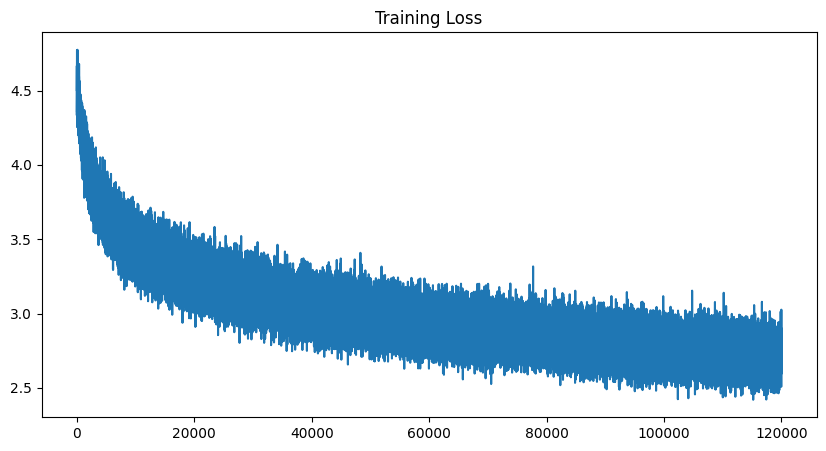

In [130]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(training_loss_logger[1000:])
_ = plt.title("Training Loss")

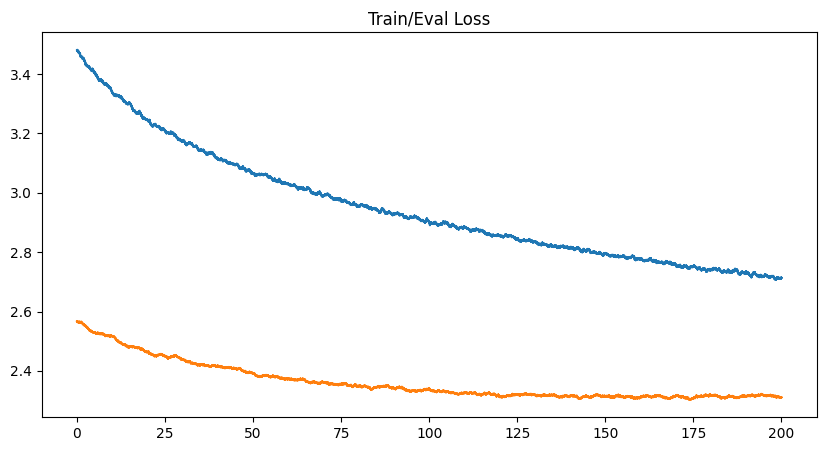

In [131]:
window_size = 512
_ = plt.figure(figsize=(10, 5))

train_data = np.convolve(np.array(training_loss_logger), np.ones(window_size)/window_size, mode="valid")[10000:]
eval_data = np.convolve(np.array(eval_loss_logger), np.ones(window_size)/window_size, mode="valid")[10000:]

_ = plt.plot(np.linspace(0, nepochs, len(train_data)), train_data)
_ = plt.plot(np.linspace(0, nepochs, len(eval_data)), eval_data)

_ = plt.title("Train/Eval Loss")

## Testing

In [132]:
# Create a dataloader itterable object
dataiter = next(iter(data_loader_eval))
# Sample from the itterable object
test_images, test_captions = dataiter

In [133]:
# Choose an index within the batch
index = 10
test_image = test_images[index].unsqueeze(0)

A toy dinosaur standing on a sink next to a running faucet.


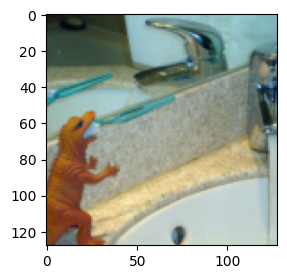

In [134]:
# Lets visualise an entire batch of images!
plt.figure(figsize = (3,3))
out = torchvision.utils.make_grid(test_image, 1, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))
print(test_captions[index])

In [135]:
# Add the Start-Of-Sentence token to the prompt to signal the network to start generating the caption
sos_token = 101 * torch.ones(1, 1).long()

# Set the temperature for sampling during generation
temp = 0.5

In [136]:
log_tokens = [sos_token]
caption_model.eval()

with torch.no_grad():
    # Encode the input image
    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        # Forward pass
        image_embedding = caption_model.encoder(test_image.to(device))

    # Generate the answer tokens
    for i in range(50):
        input_tokens = torch.cat(log_tokens, 1)

        # Decode the input tokens into the next predicted tokens
        data_pred = caption_model.decoder(input_tokens.to(device), image_embedding)

        # Sample from the distribution of predicted probabilities
        dist = Categorical(logits=data_pred[:, -1] / temp)
        next_tokens = dist.sample().reshape(1, 1)

        # Append the next predicted token to the sequence
        log_tokens.append(next_tokens.cpu())

        # Break the loop if the End-Of-Caption token is predicted
        if next_tokens.item() == 102:
            break

/tmp/ipykernel_37700/4211304649.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


In [137]:
# Convert the list of token indices to a tensor
pred_text = torch.cat(log_tokens, 1)

# Convert the token indices to their corresponding strings using the vocabulary
pred_text_strings = tokenizer.decode(pred_text[0], skip_special_tokens=True)

# Join the token strings to form the predicted text
pred_text = "".join(pred_text_strings)

Loading trained model checkpoint...
Successfully loaded checkpoint from epoch 186
Ground truth caption: A number of small birds sitting at the top of a bare tree.

Generating caption...


/tmp/ipykernel_37700/794643024.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



Generated caption: two birds are sitting on the branches of a tree.
Ground truth: A number of small birds sitting at the top of a bare tree.


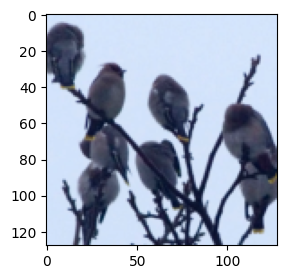

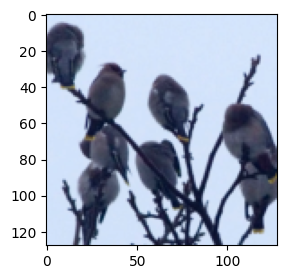

In [140]:
# Load the trained checkpoint
print("Loading trained model checkpoint...")
cp = torch.load("captioning_model.pt")
caption_model.load_state_dict(cp["model_state_dict"])
optimizer.load_state_dict(cp["optimizer_state_dict"])
training_loss_logger = cp["train_data_logger"]
eval_loss_logger = cp["eval_data_logger"]
start_epoch = cp["epoch"]
print(f"Successfully loaded checkpoint from epoch {start_epoch}")

# Set model to evaluation mode
caption_model.eval()

# Get a test image from validation set
dataiter = next(iter(data_loader_eval))
test_images, test_captions = dataiter

# Choose an image to test (index 0-127 for batch size 128)
index = 6
test_image = test_images[index].unsqueeze(0)

# Display the test image
plt.figure(figsize=(3, 3))
out = torchvision.utils.make_grid(test_image, 1, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))
print("Ground truth caption:", test_captions[index])

# Generate caption using the trained model
print("\nGenerating caption...")
sos_token = 101 * torch.ones(1, 1).long()  # Start token
temp = 0.5  # Temperature for sampling

log_tokens = [sos_token]
caption_model.eval()

with torch.no_grad():
    # Encode the input image
    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        image_embedding = caption_model.encoder(test_image.to(device))

    # Generate the caption tokens
    for i in range(50):  # Max 50 tokens
        input_tokens = torch.cat(log_tokens, 1)
        
        # Decode the input tokens
        data_pred = caption_model.decoder(input_tokens.to(device), image_embedding)
        
        # Sample from the distribution
        dist = Categorical(logits=data_pred[:, -1] / temp)
        next_tokens = dist.sample().reshape(1, 1)
        
        # Append the next token
        log_tokens.append(next_tokens.cpu())
        
        # Stop if end token is generated
        if next_tokens.item() == 102:  # End token
            break

# Convert tokens to text
pred_text = torch.cat(log_tokens, 1)
pred_text_strings = tokenizer.decode(pred_text[0], skip_special_tokens=True)
pred_text = "".join(pred_text_strings)

# Display results
plt.figure(figsize=(3, 3))
out = torchvision.utils.make_grid(test_image, 1, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

print("\nGenerated caption:", pred_text)
print("Ground truth:", test_captions[index])

a motorcycle parked next to a tree in front of a building.


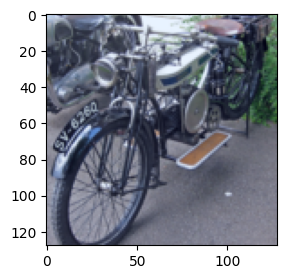

In [110]:
# Lets visualise an entire batch of images!
plt.figure(figsize = (3, 3))
out = torchvision.utils.make_grid(test_image, 1, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

# Print the predicted text
print(pred_text)